<a href="https://colab.research.google.com/github/arthyaroul/pilotage-risques-chantier/blob/main/pilotage-risques-chantier/notebooks/02_arbre_de_decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Modèle : arbre de décision

**Projet :** Pilotage des risques de chantier · Arthy Aroul & Aurélie Mahé · Bootcamp Data Essentials, Jedha (2026)

**Objectif :** tester un premier modèle interprétable. Un arbre de décision cherche des seuils (« si le coût dépasse X et que la météo est orageuse, alors risque chantier élevé »), ce qui permet de capter des effets non linéaires que la régression logistique ne voit pas.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    matthews_corrcoef,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Chargement des données

In [7]:
# Chemin du fichier (voir data/README.md pour télécharger le dataset)
# Sur Google Colab : téléverser le CSV puis utiliser "/content/bim_ai_civil_engineering_dataset.csv"
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/bim_ai_civil_engineering_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"{df.shape[0]} projets, {df.shape[1]} variables")

1000 projets, 28 variables


## 2. Préparation des données

Mêmes choix que dans les autres notebooks, pour que les modèles soient comparés sur exactement les mêmes variables.

| Variable exclue | Raison |
|---|---|
| `Project_ID` | Identifiant, aucune information prédictive |
| `Start_Date`, `End_Date` | Dates brutes |
| `Safety_Risk_Score` | **Fuite de données** : `Risk_Level` est dérivé de ce score (voir EDA) |
| `Crack_Width`, `Image_Analysis_Score` | Doublons d'information du score de risque |
| `Risk_Level` | Variable cible |

On conserve donc 21 variables explicatives (3 catégorielles, 18 numériques). `Anomaly_Detected` est gardée, mais reste à surveiller : aucun projet « Low » n'a d'anomalie détectée, ce qui laisse penser qu'elle pourrait être liée au calcul du risque.

In [8]:
target_col = "Risk_Level"
drop_cols = [
    "Project_ID", "Start_Date", "End_Date",           # identifiant et dates brutes
    "Safety_Risk_Score",                              # fuite de données
    "Crack_Width", "Image_Analysis_Score",            # doublons d'information du score
    target_col,
]

X = df.drop(columns=drop_cols)

categorical_features = X.select_dtypes(exclude="number").columns.tolist()
numeric_features = X.select_dtypes(include="number").columns.tolist()

print(f"{len(categorical_features)} variables catégorielles :", categorical_features)
print(f"{len(numeric_features)} variables numériques :", numeric_features)

3 variables catégorielles : ['Project_Type', 'Location', 'Weather_Condition']
18 variables numériques : ['Planned_Cost', 'Actual_Cost', 'Cost_Overrun', 'Planned_Duration', 'Actual_Duration', 'Schedule_Deviation', 'Vibration_Level', 'Load_Bearing_Capacity', 'Temperature', 'Humidity', 'Air_Quality_Index', 'Energy_Consumption', 'Material_Usage', 'Labor_Hours', 'Equipment_Utilization', 'Accident_Count', 'Anomaly_Detected', 'Completion_Percentage']


### Passage de 3 à 2 classes

Les classes d'origine sont déséquilibrées (50 % High, 34 % Medium, 16 % Low). On reformule la question en une décision binaire, plus actionnable : *ce chantier doit-il être audité en priorité ?*

La classe `Medium` est coupée en deux à la médiane de son `Safety_Risk_Score` : la moitié basse rejoint `Low`, la moitié haute rejoint `High`. Le score sert uniquement à construire la cible ; il n'est pas utilisé comme variable explicative.

In [9]:
y_binary = df[target_col].copy()

medium = df[df[target_col] == "Medium"].sort_values("Safety_Risk_Score")
split_point = len(medium) // 2

y_binary.loc[medium.index[:split_point]] = "Low"    # moitié basse du Medium
y_binary.loc[medium.index[split_point:]] = "High"   # moitié haute du Medium

print(y_binary.value_counts())
print(y_binary.value_counts(normalize=True).round(3))

Risk_Level
High    673
Low     327
Name: count, dtype: int64
Risk_Level
High    0.673
Low     0.327
Name: proportion, dtype: float64


### Jeux d'entraînement et de test, validation croisée, encodage

In [10]:
# Split stratifié 80 % / 20 % : même proportion High / Low dans les deux jeux
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.20, random_state=0, stratify=y_binary
)

# Validation croisée stratifiée à 5 plis (2 plis donnaient des scores trop instables)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Encodage des variables catégorielles, les numériques passent telles quelles
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

print(f"Train : {len(X_train)} projets | Test : {len(X_test)} projets")

Train : 800 projets | Test : 200 projets


In [11]:
LABELS = ["Low", "High"]
SCORING = {
    "f1_macro": "f1_macro",
    "mcc": make_scorer(matthews_corrcoef),
    "accuracy": "accuracy",
}


def evaluer(nom, y_true, y_pred):
    """Renvoie les trois métriques suivies dans le projet sur le jeu de test."""
    return {
        "Modèle": nom,
        "F1 macro": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 3),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 3),
        "Accuracy": round(accuracy_score(y_true, y_pred), 3),
    }


def afficher_matrice(y_true, y_pred, titre):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
    plt.title(titre)
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.tight_layout()
    plt.show()

## 3. Baseline naïve

Avant tout modèle, on mesure ce qu'obtient une règle sans intelligence : **prédire « High » pour tous les chantiers**. Un modèle n'est utile que s'il fait mieux que cette baseline.

Le **MCC** (coefficient de corrélation de Matthews) est la métrique de référence ici : il vaut 0 pour une prédiction au hasard ou constante, 1 pour une prédiction parfaite, et il n'est pas trompé par le déséquilibre des classes.

In [12]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

resultat_dummy = evaluer("Baseline naïve (toujours High)", y_test, y_pred_dummy)
resultat_dummy

{'Modèle': 'Baseline naïve (toujours High)',
 'F1 macro': 0.403,
 'MCC': 0.0,
 'Accuracy': 0.675}

En prédisant toujours « High », on a déjà **67,5 % de bonnes réponses** (135 projets High sur 200), un F1 macro d'environ 0,40 et un MCC de 0. C'est la barre à dépasser.

## 4. Arbre de décision

Le déséquilibre des classes est corrigé avec `class_weight="balanced"`, qui donne plus de poids aux erreurs sur la classe minoritaire (Low). SMOTE, testé pendant le projet, n'est pas ajouté en plus : combiner les deux corrige le déséquilibre deux fois.

In [13]:
model_dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight="balanced",
)

pipeline_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", model_dt),
])

cv_dt = cross_validate(pipeline_dt, X_train, y_train, cv=cv, scoring=SCORING)

for metrique in SCORING:
    scores = cv_dt[f"test_{metrique}"]
    print(f"CV {metrique:<9}: {scores.mean():.3f} (+/- {scores.std():.3f})")

CV f1_macro : 0.480 (+/- 0.012)
CV mcc      : -0.019 (+/- 0.019)
CV accuracy : 0.511 (+/- 0.030)


### Évaluation sur le jeu de test

In [14]:
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)

print(classification_report(y_test, y_pred_dt, labels=LABELS, digits=3, zero_division=0))

resultats = pd.DataFrame([resultat_dummy, evaluer("Arbre de décision", y_test, y_pred_dt)])
resultats

              precision    recall  f1-score   support

         Low      0.328     0.646     0.435        65
        High      0.681     0.363     0.473       135

    accuracy                          0.455       200
   macro avg      0.504     0.505     0.454       200
weighted avg      0.566     0.455     0.461       200



,Modèle,F1 macro,MCC,Accuracy
0,Baseline naïve (toujours High),0.403,0.000,0.675
1,Arbre de décision,0.454,0.009,0.455


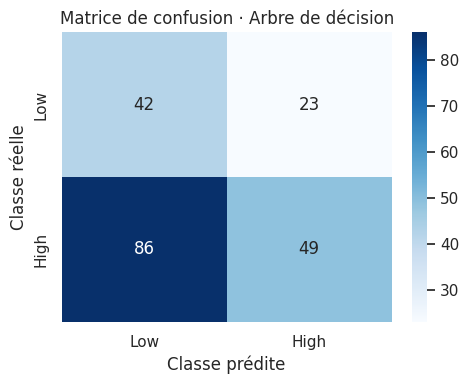

In [15]:
afficher_matrice(y_test, y_pred_dt, "Matrice de confusion · Arbre de décision")

### Visualisation des premiers niveaux de l'arbre

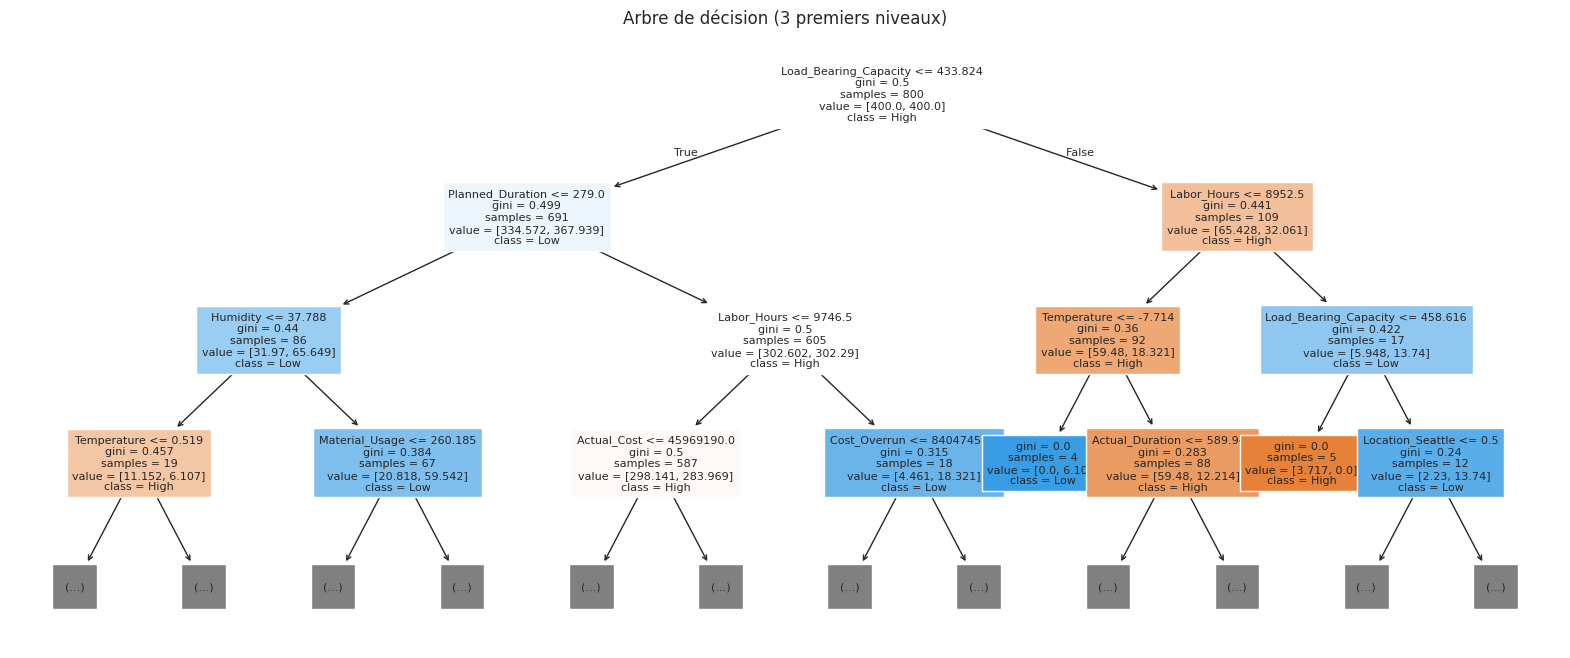

In [16]:
plt.figure(figsize=(20, 8))
plot_tree(
    pipeline_dt.named_steps["classifier"],
    feature_names=pipeline_dt.named_steps["preprocessor"].get_feature_names_out(),
    class_names=pipeline_dt.named_steps["classifier"].classes_,
    max_depth=3,
    filled=True,
    fontsize=8,
)
plt.title("Arbre de décision (3 premiers niveaux)")
plt.show()

### Variables les plus utilisées par l'arbre

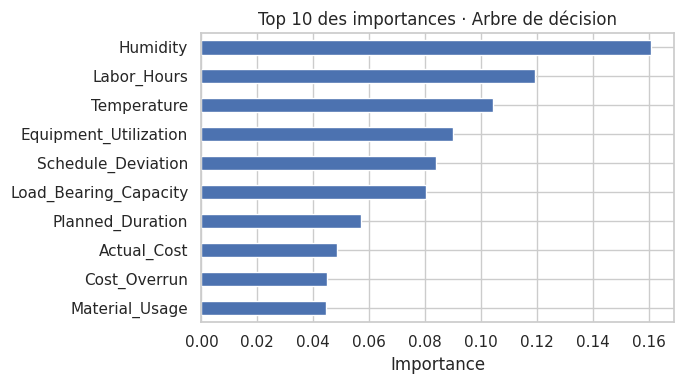

In [17]:
feature_names = pipeline_dt.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline_dt.named_steps["classifier"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

feat_imp.sort_values().plot(kind="barh", figsize=(7, 4))
plt.title("Top 10 des importances · Arbre de décision")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Attention à l'interprétation** : un modèle qui ne fait pas mieux que le hasard répartit ses « importances » sur du bruit. Ce classement ne doit donc pas être lu comme une liste de facteurs de risque réels.

## 5. Conclusion

L'arbre de décision **ne fait pas mieux que la baseline naïve** : son MCC reste proche de 0 et son accuracy est inférieure aux 67,5 % obtenus en prédisant toujours « High ». Les seuils qu'il trouve ne correspondent à aucune structure réelle dans les données, ce qui confirme le constat de l'EDA : le signal est quasi inexistant.

Suite : random forest et comparaison de tous les modèles dans le notebook `03_random_forest_et_comparaison.ipynb`.